# Лекция 2 (Тема 1.2). Элементарная теория чисел

---

## Делимость и деление с остатком

- Определение: $a \mid b$, если $b = aq$ для некоторого целого $q$.
- Базовые свойства делимости:
  - $a\mid a$ (рефлексивность);
  - $1\mid a$ и $a\mid 0$ для любого целого $a$ (единица делит всё; всё делит ноль);
  - $a\mid b,\ b\mid c \Rightarrow a\mid c$ (транзитивность);
  - $a\mid b,\ b\mid a \Rightarrow a =\pm b$ (антисимметричность*);
  - $a\mid b,\ a\mid c \Rightarrow a \mid (b\pm c)$;
  - $a\mid b \Rightarrow a\mid bc$ для любого целого $c$;
  - $a\mid b,\ a\mid c \Rightarrow a \mid (xb+yc)$ для любых целых $x,y$;
- Теорема о делении с остатком: для любых $a, b\in\mathbb{Z}$, $b>0$, существуют единственные $q, r$ с $a = bq + r$, $0 \le r < b$.

In [2]:
# .divides() проверяет делимость:
print(5.divides(17)) # 5 | 17 ?
print(4.divides(20)) # 4 | 20 ?


False
True


In [3]:
# деление с остатком: divmod(a, b) сразу даёт пару (q, r)
a, b = 17, 5

q, r = divmod(a, b)
print(f"{a} = {b}*{q} + {r},  0 <= {r} < {b}")
a == b * q + r and 0 <= r < b


17 = 5*3 + 2,  0 <= 2 < 5


True

In [4]:
# Те же q и r по отдельности через операторы // и %
print(a // b, a % b)
(a // b, a % b) == (q, r)

3 2


True

In [5]:
# деление с остатком для отрицательного a: Sage всегда даёт 0 <= r < b
c = -17
qc, rc = divmod(c, b)
print(f"{c} = {b}*{qc} + {rc}")
assert 0 <= rc < b

-17 = 5*-4 + 3


---

## НОД, алгоритм Евклида и тождество Безу

- Наибольший общий делитель (НОД) $d=\gcd(a,b)$ — натуральное число такое, что 
  - $d\mid a$ и $d\mid b$;
  - $c\mid a$ и $c\mid b \Rightarrow c\mid d$.
- Теорема (тождество Безу): для любых $a,b$ существуют целые $x,y$, такие что $ax + by = \gcd(a,b)$.
- Следствие: если $\gcd(a,b)=1$ (т.е. взаимно просты), то $ax+by=1$ разрешимо.
- Множество $\{ax+by : x,y\in\mathbb{Z}\}$ — в точности все кратные $d = \gcd(a,b)$
- Алгоритм Евклида: $\gcd(a,b) = \gcd(b,\, a \bmod b)$ при $b\ne0$, с базой рекурсии $\gcd(a,0)=|a|$;

Идея восстановления коэффициентов Безу — "раскрутка назад" шагов алгоритма Евклида. Общая схема: 

$a=bq_0+r_1$, $b=r_1q_1+r_2$, $r_1=r_2q_2+r_3$, $\dots$, $r_{n-2}=r_{n-1}q_{n-1}+r_n$, $r_{n-1}=r_nq_n$ (остаток $0$).

Последовательность остатков $b>r_1>r_2>\dots>r_n>0$ строго убывает и ограничена снизу нулём $\Rightarrow$ процедура останавливается за конечное число шагов, и $r_n=\gcd(a,b)$

In [6]:
# пример
gcd(93, 42)

3

In [7]:
# ручная трассировка алгоритма Евклида через цепочку %
a, b = 93, 42
x, y = a, b
while y != 0:
    print(f"{x} = {x // y}*{y} + {x % y}")
    x, y = y, x % y
print("gcd =", x)

93 = 2*42 + 9
42 = 4*9 + 6
9 = 1*6 + 3
6 = 2*3 + 0
gcd = 3


In [8]:
# xgcd(a, b) возвращает (d, x, y) с d = a*x + b*y
d, x, y = xgcd(93, 42)
print(d, x, y)
d == 93*x + 42*y

3 5 -11


True

In [9]:
# взаимно простая пара
d2, x2, y2 = xgcd(240, 47)
print(d2, x2, y2)
d2 == 240*x2 + 47*y2

1 19 -97


True

---

## Простые числа

- Число $p>1$ — простое: делители только $1$ и $p$.
- Теорема (Евклид): простых чисел бесконечно много.
- Идея доказательства бесконечности простых: если бы простых было конечно $p_1,\dots,p_n$, число $N=p_1\cdots p_n+1$ не делится ни на одно из них $\Rightarrow$ у него есть новый простой делитель — противоречие.
- Основная теорема арифметики: каждое целое $n>1$ представимо в виде $n = p_1^{a_1}p_2^{a_2}\cdots p_k^{a_k}$, где $p_1<\dots<p_k$ — простые, $a_i\ge1$, и такое разложение единственно.
- Теорема (Адамар, Валле-Пуссен): пусть $\pi(x)$ — количество простых чисел, не превосходящих $x$, тогда $\pi(x) \sim x/\ln x$ при $x\to\infty$.

In [10]:
# is_prime / factor / prime_range
print(is_prime(97), is_prime(98))
print(factor(360))
print(prime_range(50))

True False
2^3 * 3^2 * 5
[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]


In [11]:
# рост времени факторизации
n_small = random_prime(10^5) * random_prime(10^5)
n_large = random_prime(10^30) * random_prime(10^30)
print(n_small, n_large)

%time factor(n_small)
%time factor(n_large)

446808629 838894528155833854638790687661409729834626311344439936481161
CPU times: user 43 μs, sys: 28 μs, total: 71 μs
Wall time: 93 μs
CPU times: user 1.64 s, sys: 10.1 ms, total: 1.65 s
Wall time: 1.66 s


875165448147755948154020042299 * 958555356511517121822337718539

In [12]:
# идея доказательства Евклида: N = p_1*...*p_n + 1 не делится ни на одно p_i,
# но необязательно само простое — у него просто будет новый простой делитель
n = 6
ps = prime_range(0, 40)[:n]
N = prod(ps) + 1
print(ps, "->", N)
print(factor(N))
# новый простой делитель не входит в исходный список ps
all(p not in ps for p, _ in factor(N))

[2, 3, 5, 7, 11, 13] -> 30031
59 * 509


True

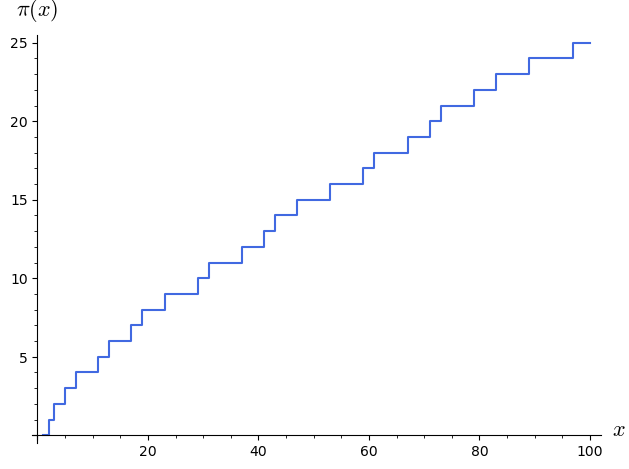

In [13]:
#\pi(x) на небольшом интервале
N1 = 100
pi_points = [(x, prime_pi(x)) for x in srange(1, N1 + 1)]
p1 = plot_step_function(pi_points, color='royalblue', thickness=1.5)
p1.show(axes_labels=['$x$', '$\\pi(x)$'])

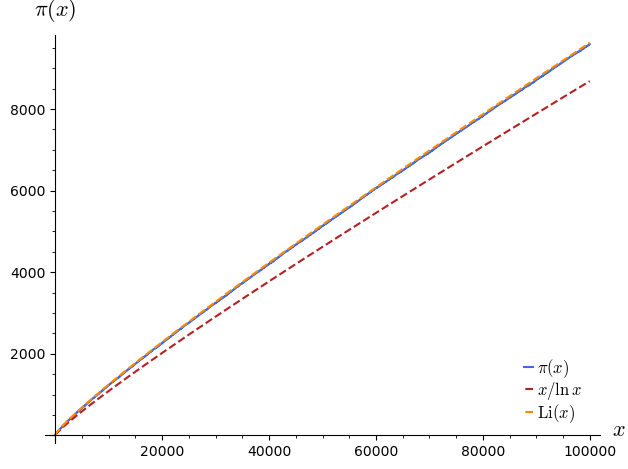

In [ ]:
#\pi(x) на большем интервале

xs = srange(10, 10^5, 10)
pi_vals = [(x, prime_pi(x)) for x in xs]
approx_vals = [(x, x / log(x.n())) for x in xs]
li_vals = [(x, Li(x.n())) for x in xs]

p4 = plot_step_function(pi_vals, color='royalblue', thickness=1.5, legend_label='$\\pi(x)$')
p4 += line(approx_vals, color='firebrick', thickness=1.5, linestyle='--', legend_label='$x/\\ln x$')
p4 += line(li_vals, color='darkorange', thickness=1.5, linestyle='--', legend_label='$\\operatorname{Li}(x)$')

p4.show(axes_labels=['$x$', '$\\pi(x)$'], legend_loc='lower right', legend_font_size=12, legend_frameon=False)

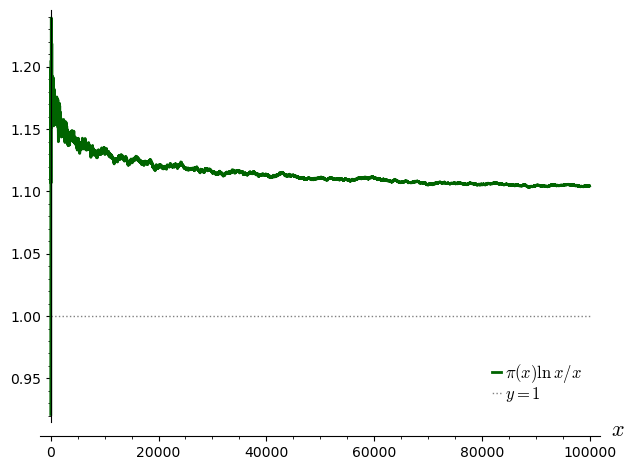

In [15]:
#cходимость $\pi(x) \sim x/\ln x$ при $x\to\infty$

ratio_vals = [(x, prime_pi(x) * log(x.n()) / x) for x in xs]

p3 = line(ratio_vals, color='darkgreen', thickness=2,
          legend_label='$\\pi(x)\\ln x / x$')
p3 += line([(xs[0], 1), (xs[-1], 1)], color='gray', linestyle=':', legend_label='$y=1$')

p3.show(axes_labels=['$x$', ''], legend_loc='lower right', legend_font_size=12, legend_frameon=False)

---

## Некоторые открытые проблемы о простых

- Гипотеза Гольдбаха: Каждое чётное $n>2$ — сумма двух простых.
- Гипотеза о простых-близнецах: Бесконечно ли пар $(p, p+2)$?
- Гипотеза Лежандра: Для любого $n\ge1$ между $n^2$ и $(n+1)^2$ всегда есть простое число.
- Простые вида $n^2+1$: Бесконечно ли простых такого вида?

In [16]:
# Гольдбах: перебором по prime_range(n) найти разложение n = p + q
def goldbach_pair(n):
    for p in prime_range(n):
        if is_prime(n - p):
            return (p, n - p)
    return None

N = 20
evens = [2*k for k in range(2, N + 2)]
for n in evens:
    print(n, "=", goldbach_pair(n))

all(goldbach_pair(n) is not None for n in evens)


4 = (2, 2)
6 = (3, 3)
8 = (3, 5)
10 = (3, 7)
12 = (5, 7)
14 = (3, 11)
16 = (3, 13)
18 = (5, 13)
20 = (3, 17)
22 = (3, 19)
24 = (5, 19)
26 = (3, 23)
28 = (5, 23)
30 = (7, 23)
32 = (3, 29)
34 = (3, 31)
36 = (5, 31)
38 = (7, 31)
40 = (3, 37)
42 = (5, 37)


True

In [17]:
# Близнецы: prime_range + фильтр пар (p, p+2), обе из которых простые
ps = prime_range(1000)
twins = [(p, p + 2) for p in ps if is_prime(p + 2)]
print(len(twins), "пар из первых", len(ps), "простых")
print(twins[:10])

35 пар из первых 168 простых
[(3, 5), (5, 7), (11, 13), (17, 19), (29, 31), (41, 43), (59, 61), (71, 73), (101, 103), (107, 109)]


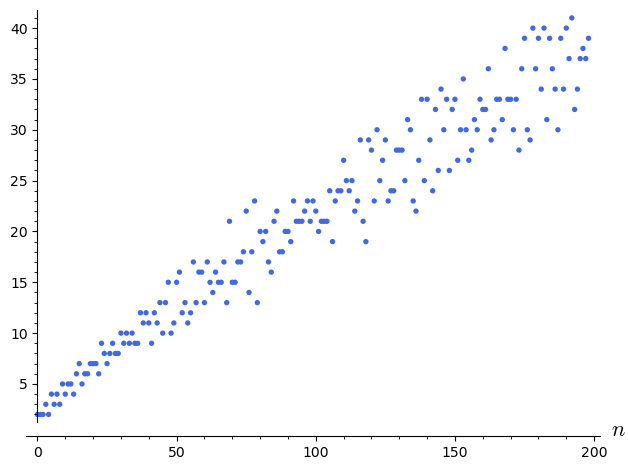

In [18]:
# Лежандр: для растущих n prime_range(n^2, (n+1)^2) непусто
counts = [len(prime_range(n^2, (n + 1)^2)) for n in range(1, 200)]
#print(min(counts))
#print(all(c > 0 for c in counts))

list_plot(counts, plotjoined=False, size=15, color='royalblue', axes_labels=['$n$', ''])


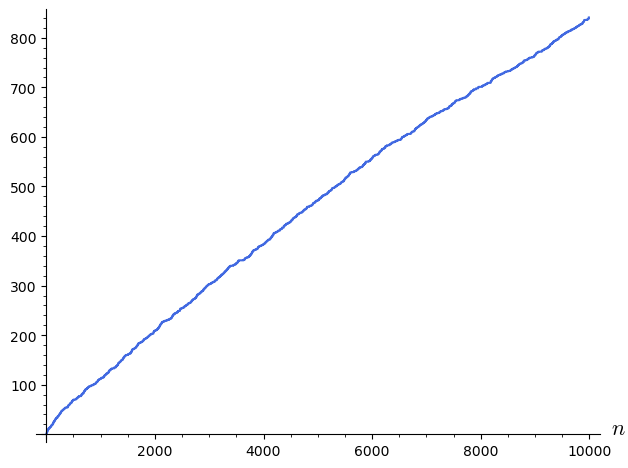

In [19]:
# Простые вида n^2+1: фильтр is_prime(n^2+1) по диапазону n
vals = [n for n in range(1, 10000) if is_prime(n^2 + 1)]
cum_points = [(n, len([v for v in vals if v <= n])) for n in range(1, 10000, 10)]
plot_step_function(cum_points, color='royalblue', thickness=1.5,axes_labels=['$n$', ''])


---

## Сравнения по модулю $n$

- Определение: $a \equiv b \pmod n \iff n \mid (a-b)$.
- Сравнение по модулю $n$ — отношение эквивалентности:
  - $a\equiv a\pmod n$ (рефлексивность);
  - $a\equiv b\pmod n \Rightarrow b\equiv a\pmod n$ (симметричность);
  - $a\equiv b,\ b\equiv c\pmod n \Rightarrow a\equiv c\pmod n$ (транзитивность).
- $\mathbb{Z}$ разбивается на $n$ классов эквивалентности (вычетов): $\overline{0}, \overline{1}, \dots, \overline{n-1}$;
- Сравнения совместимы со сложением и умножением.

In [20]:
# сравнимость и проверка по определению
a, b, n = 23, 8, 5

print(a % n, b % n)
print(Mod(a, n), Mod(b, n))
print(Mod(a, n) == Mod(b, n))

print((a - b) % n == 0)

3 3
3 3
True
True


---

## Мотивация: сравнения как метод исключения решений

- Если уравнение имеет решение в целых числах, то оно имеет решение и по любому модулю $n$
- Отсутствие решения по какому-то модулю $n$ доказывает отсутствие решения в $\mathbb{Z}$
- Пример: уравнение $x^2+y^2=4k+3$ не имеет целых решений: квадраты по модулю $4$ принимают только значения $0,1$, а их сумма никогда не даёт $3\pmod4$
- Пример: уравнение $x^2-3y^2=2$ не имеет целых решений: квадраты по модулю $3$ равны $0$ или $1$, значение $2$ не достигается

In [21]:
# возможные значения квадратов по модулю 4 и по модулю 3
print([i^2 % 4 for i in range(4)])   # {0, 1} -> сумма двух таких значений никогда не даёт 3 (mod 4)
print([i^2 % 3 for i in range(3)])   # {0, 1} -> значение 2 не достигается

# x^2 + y^2 = 4k + 3: полным перебором в диапазоне убеждаемся, что решений нет
sols = [(x, y, k) for k in range(20) for x in range(-20, 21) for y in range(-20, 21)
        if x^2 + y^2 == 4*k + 3]
print(sols)

# x^2 - 3*y^2 = 2: аналогично
sols2 = [(x, y) for x in range(-50, 51) for y in range(-50, 51) if x^2 - 3*y^2 == 2]
print(sols2)

[0, 1, 0, 1]
[0, 1, 1]
[]
[]


---

## Кольцо $\mathbb{Z}/n\mathbb{Z}$

- Определение: (коммутативное) кольцо с единицей — множество $R$ с двумя операциями $+,\times$ и выделенными элементами $0,1\in R$, для которых выполнено:
  - $(a+b)+c=a+(b+c)$ и $a+b=b+a$ (ассоциативность и коммутативность $+$);
  - $a+0=a$ для любого $a\in R$ (нейтральный элемент для $+$);
  - для каждого $a\in R$ существует $-a\in R$ с $a+(-a)=0$ (противоположный для $+$);
  - $(a\times b)\times c=a\times(b\times c)$ и $a\times b=b\times a$ (ассоциативность и коммутативность $\times$);
  - $a\times1=a$ для любого $a\in R$ (нейтральный элемент для $\times$);
  - $a\times(b+c)=a\times b+a\times c$ (дистрибутивность).
- $\mathbb{Z}/n\mathbb{Z}$ — множество классов вычетов с операциями сложения и умножения по модулю $n$ — коммутативное кольцо с единицей

In [22]:
# таблицы сложения и умножения
for n in [2, 3]:
    R = Zmod(n) # кольцо Z/nZ
    print(f"--- Z/{n}Z ---")
    print(R.addition_table(names='elements'))
    print(R.multiplication_table(names='elements'))

--- Z/2Z ---
+  0 1
 +----
0| 0 1
1| 1 0

*  0 1
 +----
0| 0 0
1| 0 1

--- Z/3Z ---
+  0 1 2
 +------
0| 0 1 2
1| 1 2 0
2| 2 0 1

*  0 1 2
 +------
0| 0 0 0
1| 0 1 2
2| 0 2 1



In [23]:
# таблица умножения и обратимые элементы
n=12
R = Zmod(n)
invertible = [a for a in R if a.is_unit()]
print(f"--- Z/{n}Z ---")
print(R.multiplication_table(names='elements'))
print("обратимые элементы:", invertible)

--- Z/12Z ---
 *   0  1  2  3  4  5  6  7  8  9 10 11
  +------------------------------------
 0|  0  0  0  0  0  0  0  0  0  0  0  0
 1|  0  1  2  3  4  5  6  7  8  9 10 11
 2|  0  2  4  6  8 10  0  2  4  6  8 10
 3|  0  3  6  9  0  3  6  9  0  3  6  9
 4|  0  4  8  0  4  8  0  4  8  0  4  8
 5|  0  5 10  3  8  1  6 11  4  9  2  7
 6|  0  6  0  6  0  6  0  6  0  6  0  6
 7|  0  7  2  9  4 11  6  1  8  3 10  5
 8|  0  8  4  0  8  4  0  8  4  0  8  4
 9|  0  9  6  3  0  9  6  3  0  9  6  3
10|  0 10  8  6  4  2  0 10  8  6  4  2
11|  0 11 10  9  8  7  6  5  4  3  2  1

обратимые элементы: [1, 5, 7, 11]


---

## Китайская теорема об остатках

- Если $n = p_1^{e_1}\cdots p_k^{e_k}$, то система сравнений $x\equiv a_i \pmod{p_i^{e_i}}$, $i=1,\dots,k$, имеет единственное решение по модулю $n$.
- Пример: $p=3,\ q=5,\ n=15$. Система $x\equiv2\pmod3,\ x\equiv3\pmod5$ имеет единственное решение по модулю $15$: $x=8$.
- Эквивалентная формулировка — изоморфизм колец: $\mathbb{Z}/n\mathbb{Z} \cong \mathbb{Z}/p_1^{e_1}\mathbb{Z}\times\cdots\times\mathbb{Z}/p_k^{e_k}\mathbb{Z}$
- Изоморфизм колец $\psi: R\to S$ --- это биекция, сохраняющая операции: $\psi(a+b)=\psi(a)+\psi(b)$, $\psi(ab)=\psi(a)\psi(b)$, $\psi(1_R)=1_S$.
- Частный случай для $n=pq$: $\mathbb{Z}/n\mathbb{Z}\cong\mathbb{Z}/p\mathbb{Z}\times\mathbb{Z}/q\mathbb{Z}$.

In [24]:
# Пример: 
x = crt([2, 3], [3, 5]) # crt() собирает решение системы сравнений
print(x)
x % 3 == 2 and x % 5 == 3

8


True

In [25]:
# другой пример: тройка взаимно простых модулей
x3 = crt([2, 3, 4], [3, 5, 7])
print(x3)
x3 % 3 == 2 and x3 % 5 == 3 and x3 % 7 == 4

53


True

In [26]:
# Китайская теорема об остатках: Z/pqZ ≅ Z/pZ × Z/qZ

p, q = 3, 5
n = p * q
Rn, Rp, Rq = Zmod(n), Zmod(p), Zmod(q)
assert gcd(p, q) == 1, "p и q должны быть взаимно просты!"

# Отображение "туда": x mod pq  |->  (x mod p, x mod q) ---
def to_pair(x):
    x = Rn(x)
    return (Rp(x), Rq(x))

# Отображение "обратно" по явной формуле CRT ---
# x ≡ a1 (mod p), x ≡ a2 (mod q)  =>
# x = a1 * q * (q^{-1} mod p) + a2 * p * (p^{-1} mod q)   (mod pq)
def from_pair(a1, a2):
    inv_q_mod_p = inverse_mod(q, p)
    inv_p_mod_q = inverse_mod(p, q)
    x = (Integer(a1) * q * inv_q_mod_p + Integer(a2) * p * inv_p_mod_q) % n
    return Rn(x)

# Проверка, что это действительно взаимно обратные биекции
print("Проверка биекции на всех элементах Z/{}Z:".format(n))
for x in range(n):
    pair = to_pair(x)
    x_back = from_pair(*pair)
    status = "OK" if Rn(x) == x_back else "FAIL"
    print(f"  {x:2d} -> {tuple(int(t) for t in pair)} -> {x_back}   [{status}]")
    assert Rn(x) == x_back

# Согласованность операций
print("\nСогласованность арифметики со случайными элементами:")
for _ in range(3):
    a, b = Rn.random_element(), Rn.random_element()
    for op, name in [(lambda u, v: u + v, "+"), (lambda u, v: u * v, "*")]:
        lhs = op(a, b)
        rhs = (op(Rp(a), Rp(b)), op(Rq(a), Rq(b)))
        print(f"  ({a} {name} {b}) mod {n} = {lhs}  <->  {rhs}")
        assert (Rp(lhs), Rq(lhs)) == rhs

Проверка биекции на всех элементах Z/15Z:
   0 -> (0, 0) -> 0   [OK]
   1 -> (1, 1) -> 1   [OK]
   2 -> (2, 2) -> 2   [OK]
   3 -> (0, 3) -> 3   [OK]
   4 -> (1, 4) -> 4   [OK]
   5 -> (2, 0) -> 5   [OK]
   6 -> (0, 1) -> 6   [OK]
   7 -> (1, 2) -> 7   [OK]
   8 -> (2, 3) -> 8   [OK]
   9 -> (0, 4) -> 9   [OK]
  10 -> (1, 0) -> 10   [OK]
  11 -> (2, 1) -> 11   [OK]
  12 -> (0, 2) -> 12   [OK]
  13 -> (1, 3) -> 13   [OK]
  14 -> (2, 4) -> 14   [OK]

Согласованность арифметики со случайными элементами:
  (5 + 8) mod 15 = 13  <->  (1, 3)
  (5 * 8) mod 15 = 10  <->  (1, 0)
  (10 + 3) mod 15 = 13  <->  (1, 3)
  (10 * 3) mod 15 = 0  <->  (0, 0)
  (9 + 6) mod 15 = 0  <->  (0, 0)
  (9 * 6) mod 15 = 9  <->  (0, 4)


In [27]:
# Что ломается, если p, q не взаимно просты
print("\nКонтрпример: p, q не взаимно просты (p=q=3) — биекции нет")
p2, q2 = 3, 9
seen = {}
collisions = 0
for x in range(p2 * q2):
    pair = (x % p2, x % q2)
    if pair in seen:
        collisions += 1
    seen[pair] = x
print(f"  Из {p2*q2} элементов получили только {len(seen)} различных пар,"
      f" т.е. {collisions} коллизий — отображение не инъективно.")


Контрпример: p, q не взаимно просты (p=q=3) — биекции нет
  Из 27 элементов получили только 9 различных пар, т.е. 18 коллизий — отображение не инъективно.


---

## Поле $\mathbb{F}_p$ и функция Эйлера

- Лемма: элемент $a$ обратим в $\mathbb{Z}/n\mathbb{Z} \Leftrightarrow \gcd(a,n)=1$;
- Пример: в $\mathbb{Z}/12\mathbb{Z}$ обратимы $\{1,5,7,11\}$, не обратимы $\{0,2,3,4,6,8,9,10\}$.
- Если $n=p$ простое, то $\mathbb{Z}/p\mathbb{Z} = \mathbb{F}_p$ — поле (обратимость для $\times$).
- Малая теорема Ферма: если $p$ простое и $p \nmid a$, то $a^{p-1} \equiv 1 \pmod p$;
- Пример: $p=7,\ a=3$: $3^6 = 729 = 104\cdot7+1 \equiv 1\pmod7$.
- Функция Эйлера $\varphi(n)$ — число классов, обратимых по модулю $n$;
- Для простого $p$: $\varphi(p)=p-1$;
- Для $n=pq$ (различные простые): $\varphi(n)=\varphi(p)\varphi(q)=(p-1)(q-1)$.
- Теорема Эйлера: если $\gcd(a,n)=1$, то $a^{\varphi(n)} \equiv 1 \pmod n$.
- Следствие: если $\gcd(a,n)=1$, то $a^{k\varphi(n)+1} \equiv a \pmod n$ для любого $k\ge0$.

In [31]:
# обратимость
Fp = Zmod(7) # на самом деле поле Fp = GF(7)
Rn = Zmod(12)  # кольцо, составной модуль для сравнения

print("Zmod(7): все ненулевые элементы обратимы?",
      all(a.is_unit() for a in Fp if a != 0))
print("Zmod(12): все ненулевые элементы обратимы?",
      all(a.is_unit() for a in Rn if a != 0))

Zmod(7): все ненулевые элементы обратимы? True
Zmod(12): все ненулевые элементы обратимы? False


In [29]:
RN = Zmod(700000000)

In [32]:
#пример
p, a = 7, 3
print(f"{a}^{p-1} mod {p} =", power_mod(a, p-1, p))
power_mod(a, p-1, p) == 1

3^6 mod 7 = 1


True

In [33]:
# функция Эйлера
print(euler_phi(7), euler_phi(12), euler_phi(360))

6 4 96


In [34]:
# Мультипликативность phi(mn) = phi(m)*phi(n) для взаимно простых m, n
m, n = 3, 5
# m, n = 8, 9
print(gcd(m, n), euler_phi(m*n), euler_phi(m) * euler_phi(n))
euler_phi(m*n) == euler_phi(m) * euler_phi(n)

1 8 8


True

In [37]:
# F_p^* - циклическая: есть элемент степени которого покрывают всю группу
p = 7
g = GF(p).multiplicative_generator()
powers = [g^k for k in range(1, p)]
print(g, sorted(powers, key=lambda x: x.lift()))
set(powers) == set(GF(p)) - {GF(p)(0)}

3 [1, 2, 3, 4, 5, 6]


True

---

## Идея RSA: асимметрия умножения и факторизации

- Наблюдение: перемножить два больших различных простых $p, q$ легко; восстановить $p,q$ по $n=pq$ (факторизовать) — вычислительно тяжело для больших $n$

In [38]:
# два случайных простых из диапазона 10^3; при таком небольшом диапазоне
# шанс случайно вытащить одинаковое простое дважды не совсем ничтожен, поэтому проверяем
p = random_prime(10^3)
q = random_prime(10^3)
while q == p:
    q = random_prime(10^3)
n = p * q
print(p, q, p != q, n)

317 17 True 5389


In [39]:
# исполняемый замер асимметрии умножения и факторизации
import time
rows = []
for bits in [10^10, 10^20, 10^30]:
    p, q = random_prime(bits), random_prime(bits)
    t0 = time.time(); pq = p * q; t_mul = time.time() - t0
    t0 = time.time(); factor(pq); t_fac = time.time() - t0
    rows.append((bits, t_mul, t_fac))
    print(f"~{len(str(bits))*1}-значный диапазон: умножение {t_mul:.6f}s, факторизация {t_fac:.4f}s")

# rows

~11-значный диапазон: умножение 0.000003s, факторизация 0.0014s
~21-значный диапазон: умножение 0.000003s, факторизация 0.0256s
~31-значный диапазон: умножение 0.000001s, факторизация 1.3045s


---

## Конструкция RSA

- Выбираем два различных простых $p, q$, полагаем $n=pq$, $\varphi(n) = (p-1)(q-1)$
  - если $p=q$, формула $\varphi(n)=(p-1)(q-1)$ неверна: $n=p^2$ и $\varphi(p^2)=p(p-1)$
- Выбираем $e$ взаимно простое с $\varphi(n)$; находим $d$: $ed\equiv1\pmod{\varphi(n)}$ (обратный к $e$ по модулю $\varphi(n)$)
  - $d$ существует именно благодаря тождеству Безу (обратимость по модулю $\varphi(n)$)
- Сообщение $m$: число $0\le m<n$
- Шифрование: $m^e \equiv c \pmod n$
- Расшифрование: $c^d \equiv m \pmod n$
- Корректность: при $\gcd(m,n)=1$: $c^d = m^{ed} = m^{k\varphi(n)+1} \equiv m \pmod n$;
- Для $m$ кратных $p$ или $q$ тождество тоже верно (обоснование через КТО и малую теорему Ферма)
- Сложность для Евы: она знает только публичные $n, e, c$; чтобы найти $d$, ей нужен $\varphi(n)$, а вычислить $\varphi(n)$, не зная $p,q$, по сложности равносильно факторизации $n=pq$

In [40]:
# игрушечный RSA целиком
p, q = 61, 53
n = p * q
phi = (p - 1) * (q - 1)
print("n =", n, " phi(n) =", phi)

e = 17
assert gcd(e, phi) == 1
d = inverse_mod(e, phi)
print("e =", e, " d =", d)
assert (e * d) % phi == 1

m = 65
c = power_mod(m, e, n)          # шифрование
m_dec = power_mod(c, d, n)      # расшифрование
print("m =", m, " c =", c, " расшифровано:", m_dec)
assert m_dec == m

n = 3233  phi(n) = 3120
e = 17  d = 2753
m = 65  c = 2790  расшифровано: 65


---

### RSA на схеме

```
┌───────────────────────────┐           ┌───────────────────────────┐
│           Алиса           │           │            Боб            │
│  генерирует p, q,         │           │                           |
│  n = pq, e, d;            │   n, e    │                           |
│  (p, q, d — секрет)       │──────────▶│  знает только n, e;       │
│                           │           │  шифрует:                 │
│     ----------------      │     c     │  c ≡ m^e mod n            │
|                           │◀──────────│                           |
│  расшифровывает:          │           │                           │
│  m ≡ c^d mod n,           │           │                           │
│  (легко, зная p, q)       │           │                           │
└───────────────────────────┘           └───────────────────────────┘
           │                                        │
           │ n, e                                   │ c
           ▼                                        ▼
    ┌───────────────────────────────────────────────────────────┐
    │                           Ева                             │
    │              видит n, e, c, но не p, q, d                 │
    │              чтобы найти d — нужен φ(n);                  │
    │              вычислить φ(n) без p, q ≈                    │
    │              факторизовать n (трудно)                     │
    └───────────────────────────────────────────────────────────┘
```

---

## Литература

* W. Stein, *Elementary Number Theory: Primes, Congruences, and Secrets: A Computational Approach*, 2017 ([wstein.org/ent](https://wstein.org/ent/)). Главы 1–3.
* К. Айерлэнд, М. Роузен, Классическое введение в современную теорию чисел, 1987 (Оригинал: K. Ireland, M. Rosen. *A Classical Introduction to Modern Number Theory*, 1990). Главы 1–4.
* Н. Коблиц. *Курс теории чисел и криптографии*, 2001 (Оригинал: N. Koblitz, *A Course in Number Theory and Cryptography*, 1994). Глава I. 
* И.М. Виноградов. *Основы теории чисел*, 1936 (1-е изд., есть современные переиздания). Главы 1—3.